# Assignment 2 - Inferential Statistics

> Done by Pranav Jahagirdar

## Dataset

https://www.kaggle.com/datasets/yasserh/titanic-dataset

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## SECTION 1: Data Understanding

### Tasks:

In [25]:
# load dataset
df = pd.read_csv('Titanic-Dataset.csv')

In [26]:
# dataset shape
print("\nDataset shape:", df.shape)

# column names
print("\nColumns:", df.columns)


Dataset shape: (891, 12)

Columns: Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [27]:
# missing values
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [28]:
# handling missing values

# fill Age with median
df["Age"].fillna(df["Age"].median(), inplace=True)

# fill Embarked with mode
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# drop Cabin column
df.drop("Cabin", axis=1, inplace=True)

# check again
print("\nAfter handling missing values:\n")
print(df.isnull().sum())


After handling missing values:

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_9224/1731646242.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipykernel_9224/1731646242.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

### Questions:

**1. Which columns have missing values?**  
Age, Cabin, and Embarked have missing values.


**2. What type of variables are present?**  
Numerical variables: Age, Fare, PassengerId  
Categorical variables: Sex, Embarked, Pclass  
Binary variable: Survived  
Text variables: Name, Ticket

## SECTION 2: Sampling

### Tasks:

In [29]:
# take random sample
sample = df.sample(n=100, random_state=42)

In [30]:
# population mean (Age)
population_mean = df["Age"].mean()

# sample mean (Age)
sample_mean = sample["Age"].mean()

print("Population Mean (Age):", population_mean)
print("Sample Mean (Age):", sample_mean)

Population Mean (Age): 29.36158249158249
Sample Mean (Age): 29.335


### Questions:

**1. Are sample and population mean equal?**  
No, they are not exactly equal, but they are usually close.


**2. Why do we use sampling?**  
Sampling is used to save time and effort. It is easier to analyze a smaller portion of data instead of the entire dataset, while still getting a good estimate of the population.

## SECTION 3: Central Limit Theorem (CLT)

### Tasks:

In [31]:
# take 500 samples and store means
sample_means = []

for i in range(500):
    sample = df["Age"].sample(n=30)
    sample_means.append(sample.mean())

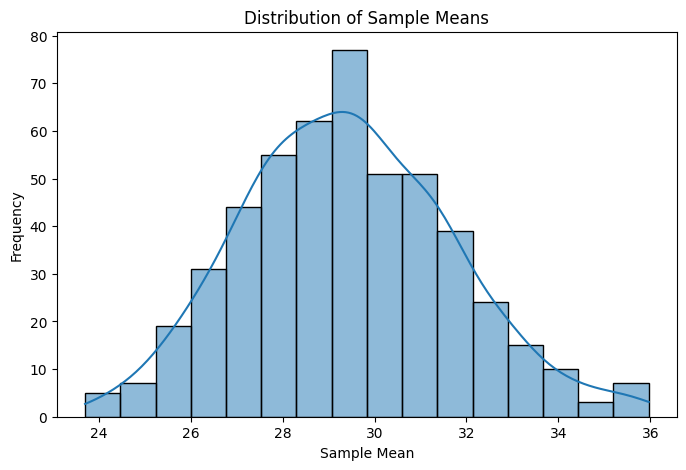

In [32]:
# plot histogram
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(sample_means, kde=True)
plt.title("Distribution of Sample Means")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()

### Questions:

**1. Does distribution look normal?**  
Yes, the distribution looks approximately normal.

**2. Why does this happen?**  
This happens because of the Central Limit Theorem. It states that when we take many samples, the distribution of their means tends to become normal, even if the original data is not perfectly normal.

## SECTION 4: Confidence Interval

### Tasks:

In [33]:
# take sample
sample = df["Age"].sample(n=100, random_state=42)

# sample mean
mean = sample.mean()

# standard deviation
std = sample.std()

print("Sample Mean:", mean)
print("Standard Deviation:", std)

Sample Mean: 29.335
Standard Deviation: 13.014765313351456


In [34]:
# calculate 95% confidence interval

import numpy as np

n = len(sample)
z = 1.96

margin_error = z * (std / np.sqrt(n))

lower = mean - margin_error
upper = mean + margin_error

print("95% Confidence Interval:", (lower, upper))

95% Confidence Interval: (np.float64(26.784105998583115), np.float64(31.885894001416887))


### Questions:

**1. What does the interval represent?**  
It represents the range in which the true population mean is likely to lie with 95% confidence.

**2. What happens if sample size increases?**  
If the sample size increases, the confidence interval becomes narrower, meaning the estimate becomes more accurate.

## SECTION 5: Hypothesis Testing (CORE)

### Problem Statement:
Do males and females have different survival rates?

**Step 1: Define Hypothesis**

H₀: There is no difference in survival rates between males and females  
H₁: There is a difference in survival rates between males and females

**Step 2: Perform Test**

In [35]:
from scipy import stats

# separate groups
male = df[df["Sex"] == "male"]["Survived"]
female = df[df["Sex"] == "female"]["Survived"]

# t-test
t_stat, p_value = stats.ttest_ind(male, female)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -19.297816550123354
P-value: 1.4060661308802594e-69


**Step 3: Decision**

In [36]:
if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to reject H0")

Reject H0


### Questions:

**1. What is p-value?**  
The p-value is the probability of getting the observed result if the null hypothesis is true.

**2. What conclusion can you draw?**  
If the p-value is less than 0.05, we reject the null hypothesis. This means there is a significant difference in survival rates between males and females. In this dataset, females generally had higher survival rates.

## SECTION 6: Real-World Interpretation

### Questions:

**1. Did gender affect survival?**  
Yes, gender affected survival. Females had a higher survival rate compared to males.

---

**2. Can we trust this conclusion? Why?**  
Yes, we can trust this conclusion because the hypothesis test gave a significant result (p-value < 0.05), which means the difference is unlikely due to chance.

---

**3. What assumptions are we making?**  
- The data is randomly sampled  
- The two groups (male and female) are independent  
- The test conditions are satisfied  

---

**4. How can this help in real-world decisions?**  
This can help in planning safety measures and emergency protocols, where certain groups may be given priority based on survival chances.

## SECTION 7: BONUS

### Problem Statement:
Does passenger class affect survival?

**Step 1: Define Hypothesis**

H₀: Passenger class does not affect survival  
H₁: Passenger class affects survival

**Step 2: Perform Test**

In [37]:
from scipy import stats

# separate groups
class1 = df[df["Pclass"] == 1]["Survived"]
class2 = df[df["Pclass"] == 2]["Survived"]
class3 = df[df["Pclass"] == 3]["Survived"]

# ANOVA test
f_stat, p_value = stats.f_oneway(class1, class2, class3)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 57.96481759091002
P-value: 2.183247415118226e-24


**Step 3: Decision**

In [38]:
if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to reject H0")

Reject H0


**Conclusion:**  
If the p-value is less than 0.05, we reject the null hypothesis. This means passenger class has a significant effect on survival. Higher class passengers had better chances of survival.